# Drifting gratings-dev

Contact: laquitainesteeve@gmail.com based on Guilhelm's guilhelm-dev branch  

Execution time: < 1 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**Requirements**:
- Run preprocessing before

## Setup

1. Create, activate (env/..yml) and setup the virtual environment :

    ```python
    python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"
    ```

2. Configure your experiment in ./params.py

In [ ]:
%load_ext autoreload
%autoreload 2

# import packages
import os
from matplotlib.pyplot import *
import numpy as np
import itertools
from tqdm.auto import tqdm
from matplotlib import pyplot as plt

# import custom packages
import params                               # import experiment parameters as global variables
import drifting_gratings_modular as analysis    # import custom module

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



## Cell 1: Load triggers times and load spike data in a list of arrays

In [ ]:
# This function calls for user input: e.g., input 3 then 2
cells, spike_times, stim_onsets, trigsinrep, seq_sep, seq_len, DG_directory = analysis.get_all_inputs_for_drifting_gratings_analysis(params) 

0 : 00_AccCheck_30Hz_16px_42sq_50%30ND
1 : 01_Swn_30Hz_48pxCh_6pxL_50%30ND
2 : 02_Chirp_50Hz_50%30ND
3 : 03_DG_50Hz_50%30ND
4 : 04_PulsingGratings-PS0_40Hz_50%30ND
5 : 05_PulsingGratings-PS1_40Hz_50%30ND
6 : 06_PulsingGratings-PS2_40Hz_50%30ND



Selected file : 03_DG_50Hz_50%30ND

Total : 344 neurons loaded 

Clusters id :
[np.uint32(0), np.uint32(1), np.uint32(2), np.uint32(3), np.uint32(4), np.uint32(5), np.uint32(6), np.uint32(7), np.uint32(8), np.uint32(9), np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17), np.uint32(18), np.uint32(19), np.uint32(20), np.uint32(21), np.uint32(22), np.uint32(23), np.uint32(24), np.uint32(25), np.uint32(26), np.uint32(27), np.uint32(28), np.uint32(29), np.uint32(30), np.uint32(31), np.uint32(32), np.uint32(33), np.uint32(34), np.uint32(35), np.uint32(36), np.uint32(37), np.uint32(38), np.uint32(39), np.uint32(40), np.uint32(41), np.uint32(42), np.uint32(43), np.uint32(44), np.uint32(45), np.uint32(46), np.uint32(47), np.uint32(48), np.uint32(49), np.uint32(50), np.uint32(51), np.uint32(52), np.uint32(53), np.uint32(54), np.uint32(55), np.uint32(56), np.uint32(57), np.uint32(58), np.uint32(59), np.uint32(60), np.uint32(61),

## Cell2: Make DG rasters

- Initialization of the random test. Uncomment only if you want to perform significance test

- The stimulus is composed of 8 moving gratings each moving at a different angle and it is displayed at 50Hz. These gratings can be displayed at different speeds and the time each single grating stays on the screen depends on the speed. If the grating is slow, it sweeps for 12 seconds. Each of the 8 gratings is repeated 4 times

- Execution time: <1 sec

In [9]:
%%time 

# compute the DG rasters
analysis.compute_dg_rasters(cells, spike_times, stim_onsets, trigsinrep, seq_len, seq_sep, DG_directory, params)

Computing Direction Selectivity : 100%|██████████| 344/344 [00:00<00:00, 3082.43it/s]

--- Cell Done ---
CPU times: user 121 ms, sys: 5 ms, total: 126 ms
Wall time: 125 ms


- Execution time: 30 secs

Plotting :   0%|          | 0/342 [00:00<?, ?it/s]

Plotting : 100%|██████████| 342/342 [00:39<00:00,  8.62it/s]


--- Cell Done ---
CPU times: user 39.3 s, sys: 441 ms, total: 39.7 s
Wall time: 39.7 s


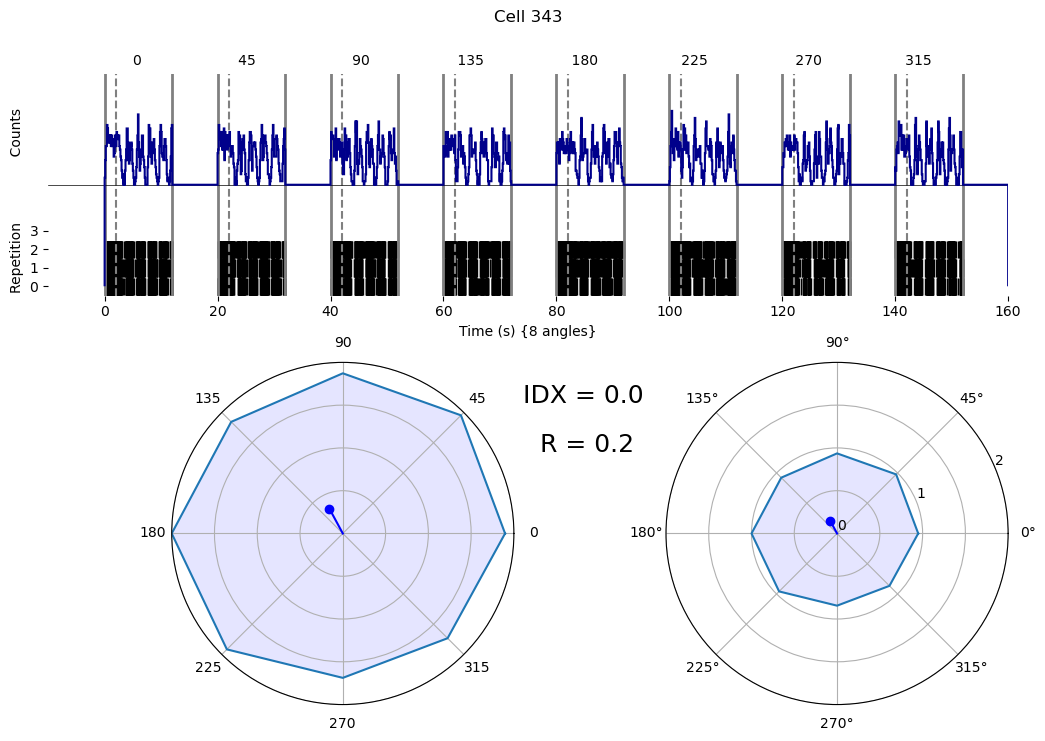

In [10]:
%%time

# create and save plots of all dg rasters
# example: plot the last one
fig = analysis.plot_dg_rasters(DG_directory, seq_sep, seq_len, params)
fig